In [1]:
pip show scikit-learn


Name: scikit-learn
Version: 1.2.2
Summary: A set of python modules for machine learning and data mining
Home-page: http://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: C:\ProgramData\anaconda3\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: imbalanced-learn
Note: you may need to restart the kernel to use updated packages.


In [11]:
import sklearn
print(sklearn.__version__)

1.8.0


# Loading Dataset

In [14]:
import numpy as np
import pandas as pd

In [31]:
df = pd.read_csv("Placement_Data_Full_Class.csv")
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [33]:
df.drop(["ssc_b","hsc_b","hsc_s","degree_t","salary"], axis=1, inplace=True)

In [37]:
df.shape

(215, 10)

In [41]:
df.isnull().sum()

sl_no             0
gender            0
ssc_p             0
hsc_p             0
degree_p          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64

# Preprocessing

In [35]:
df.head()

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p,status
0,1,M,67.00,91.00,58.00,No,55.0,Mkt&HR,58.80,Placed
1,2,M,79.33,78.33,77.48,Yes,86.5,Mkt&Fin,66.28,Placed
2,3,M,65.00,68.00,64.00,No,75.0,Mkt&Fin,57.80,Placed
3,4,M,56.00,52.00,52.00,No,66.0,Mkt&HR,59.43,Not Placed
4,5,M,85.80,73.60,73.30,No,96.8,Mkt&Fin,55.50,Placed


In [57]:
df[['gender',"workex"]].value_counts()

gender  workex
M       No        87
F       No        54
M       Yes       52
F       Yes       22
Name: count, dtype: int64

In [51]:
df.sample(5)

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p,status
180,181,M,65.00,71.5,62.8,Yes,57.0,Mkt&Fin,56.60,Placed
72,73,M,84.86,67.0,78.0,No,95.5,Mkt&Fin,68.53,Placed
21,22,F,79.00,76.0,85.0,No,95.0,Mkt&Fin,69.06,Placed
60,61,M,74.00,70.0,72.0,Yes,60.0,Mkt&Fin,57.24,Placed
131,132,F,74.90,57.0,62.0,Yes,80.0,Mkt&Fin,60.78,Placed


In [59]:
df['gender'] = df.gender.map({"M":0, "F":1})
df['workex'] = df.workex.map({"No":0, "Yes":1})
df['status'] = df.status.map({"Not Placed":0, "Placed":1})
df['specialisation'] = df.specialisation.map({"Mkt&HR":0, "Mkt&Fin":1})

In [61]:
df

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p,status
0,1,0,67.00,91.00,58.00,0,55.0,0,58.80,1
1,2,0,79.33,78.33,77.48,1,86.5,1,66.28,1
2,3,0,65.00,68.00,64.00,0,75.0,1,57.80,1
3,4,0,56.00,52.00,52.00,0,66.0,0,59.43,0
4,5,0,85.80,73.60,73.30,0,96.8,1,55.50,1
...,...,...,...,...,...,...,...,...,...,...
210,211,0,80.60,82.00,77.60,0,91.0,1,74.49,1
211,212,0,58.00,60.00,72.00,0,74.0,1,53.62,1
212,213,0,67.00,67.00,73.00,1,59.0,1,69.72,1
213,214,1,74.00,66.00,58.00,0,70.0,0,60.23,1


# Balance Dataset

In [66]:
df.head()

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p,status
0,1,0,67.00,91.00,58.00,0,55.0,0,58.80,1
1,2,0,79.33,78.33,77.48,1,86.5,1,66.28,1
2,3,0,65.00,68.00,64.00,0,75.0,1,57.80,1
3,4,0,56.00,52.00,52.00,0,66.0,0,59.43,0
4,5,0,85.80,73.60,73.30,0,96.8,1,55.50,1


In [68]:
df["status"].value_counts()

status
1    148
0     67
Name: count, dtype: int64

In [76]:
from sklearn.utils import resample

data_majority = df[df["status"]==1]
data_minority = df[df["status"]==0]

data_minority_upsampled = resample(data_minority,
        replace=True,
        n_samples=len(data_majority),
        random_state=42)

balanced_data = pd.concat([data_majority, data_minority_upsampled])

In [80]:
balanced_data["status"].value_counts()

status
1    148
0    148
Name: count, dtype: int64

# Train Test Split

In [83]:
# seperationg features and target 
X = balanced_data.copy().drop("status", axis=1)
y = balanced_data['status']

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((207, 9), (207,), (89, 9), (89,))

# Feature Scaling

In [90]:
X_train

,sl_no,gender,ssc_p,hsc_p,degree_p,workex,etest_p,specialisation,mba_p
109,110,0,52.0,63.00,65.0,1,86.00,0,56.09
31,32,1,67.0,53.00,65.0,0,64.00,0,58.32
189,190,1,54.0,77.60,69.2,0,95.65,1,66.94
138,139,1,82.0,64.00,73.0,1,96.00,1,71.77
150,151,0,71.0,58.66,58.0,1,56.00,1,61.30
...,...,...,...,...,...,...,...,...,...
187,188,0,78.5,65.50,67.0,1,95.00,1,64.86
50,51,1,75.2,73.20,68.4,0,65.00,0,62.98
42,43,0,49.0,39.00,65.0,0,63.00,1,51.21
191,192,0,67.0,61.00,72.0,0,72.00,1,61.01


In [96]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train

array([[0.50943396, 0.        , 0.23404255, ..., 0.75      , 0.        ,
        0.18290855],
       [0.14150943, 1.        , 0.55319149, ..., 0.29166667, 0.        ,
        0.26649175],
       [0.88679245, 1.        , 0.27659574, ..., 0.95104167, 1.        ,
        0.58958021],
       ...,
       [0.19339623, 0.        , 0.17021277, ..., 0.27083333, 1.        ,
        0.        ],
       [0.89622642, 0.        , 0.55319149, ..., 0.45833333, 1.        ,
        0.36731634],
       [0.55188679, 0.        , 0.74468085, ..., 0.97916667, 0.        ,
        0.72226387]])

# 1 K-nearest neighbor

In [110]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

knn_y_pred = knn.predict(X_test)

accuracy_score = accuracy_score(knn_y_pred,y_test)
accuracy_score

0.7865168539325843

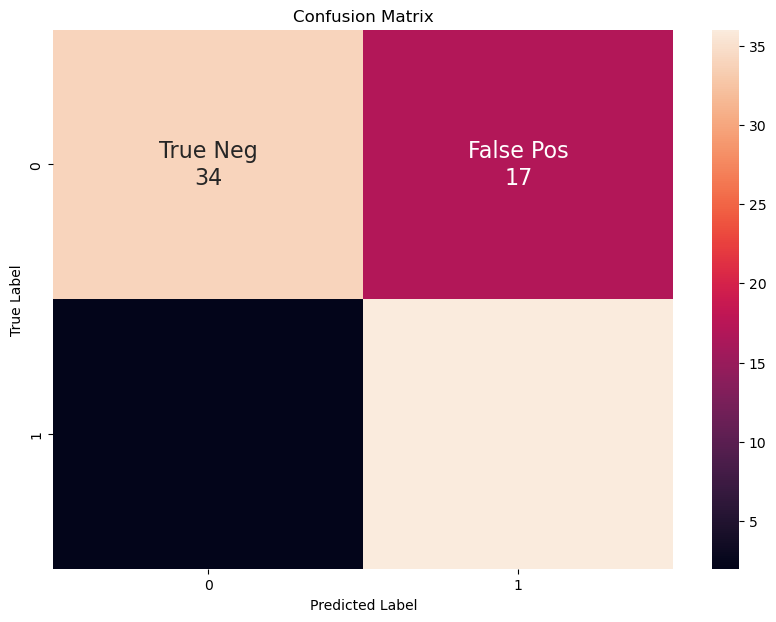

In [121]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

conf_mat = confusion_matrix(y_test, knn_y_pred)
fig = plt.figure(figsize=(10,7))

group_names = ["True Neg", "False Pos", "False Neg", "True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Decision Tree

In [129]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
decision_tree_y_pred = decision_tree.predict(X_test)
decision_tree_accuracy = decision_tree.score(X_test, y_test)
decision_tree_accuracy

0.9550561797752809

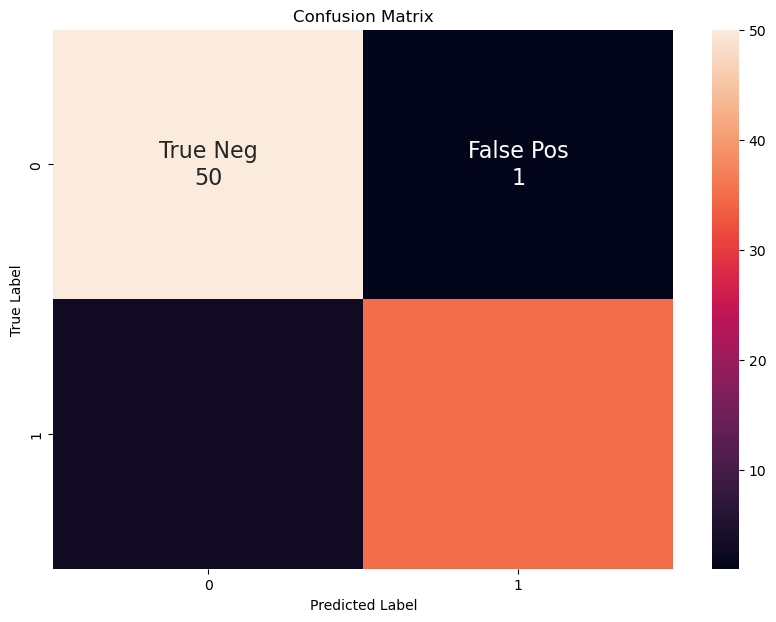

In [131]:
conf_mat = confusion_matrix(y_test, decision_tree_y_pred)
fig = plt.figure(figsize=(10,7))

group_names = ["True Neg", "False Pos", "False Neg", "True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# SVM

In [138]:
# Support Vector Machine
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train, y_train)
svm_y_pred = svc.predict(X_test)
svc_accuracy = svc.score(X_test, y_test)
svc_accuracy

0.8426966292134831

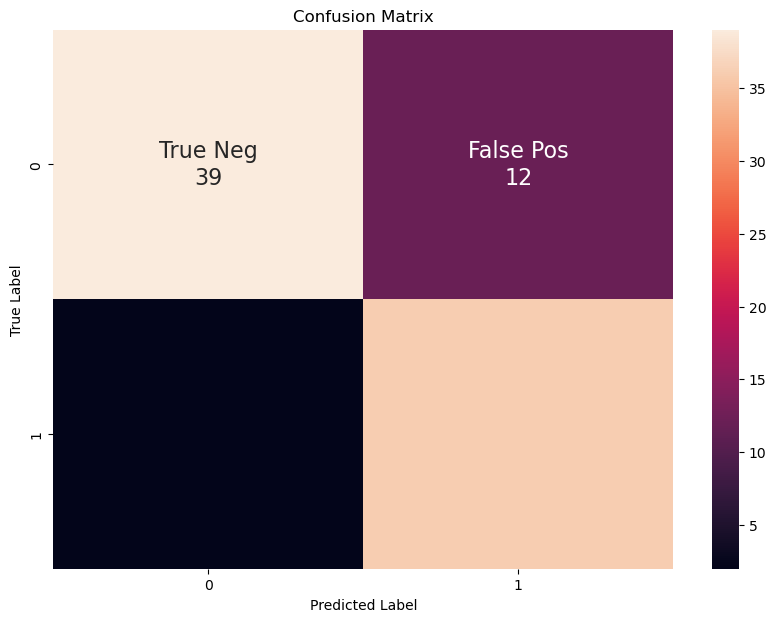

In [140]:
conf_mat = confusion_matrix(y_test, svm_y_pred)
fig = plt.figure(figsize=(10,7))

group_names = ["True Neg", "False Pos", "False Neg", "True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Random Forest

In [208]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=1000)
random_forest.fit(X_train, y_train)
random_forest_y_pred = random_forest.predict(X_test)
random_forest.score(X_train, y_train)
random_forest_accuracy = random_forest.score(X_test, y_test)
random_forest_accuracy

0.9438202247191011

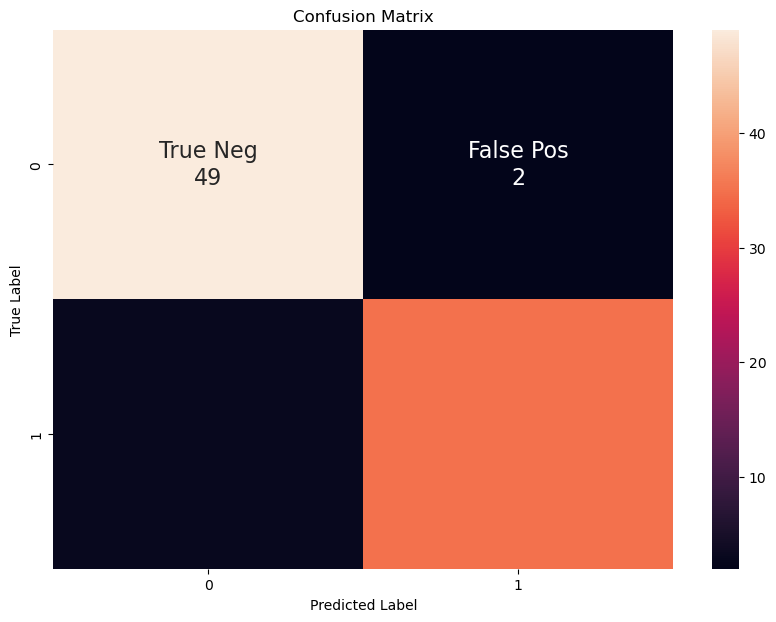

In [210]:
conf_mat = confusion_matrix(y_test, random_forest_y_pred)
fig = plt.figure(figsize=(10,7))

group_names = ["True Neg", "False Pos", "False Neg", "True Pos"]
group_counts = ["{0:0.0f}".format(value) for value in conf_mat.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(conf_mat, annot=labels, annot_kws={"size": 16}, fmt='')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Gaussian Naive Bayes

In [154]:
from sklearn.naive_bayes import GaussianNB
gaussian = GaussianNB()
gaussian.fit(X_train, y_train)
gaussian_y_pred = gaussian.predict(X_test)
gaussian_accuracy = gaussian.score(X_test, y_test)
gaussian_accuracy

0.8651685393258427

# Logistic Regression

In [157]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()
lg.fit(X_train, y_train)
lg_y_pred = lg.predict(X_test)
lg_accuracy = lg.score(X_test, y_test)
lg_accuracy

0.8426966292134831

# Single Input Predictions

In [230]:
print("Predicted Class",random_forest.predict(X_train[75].reshape(1,-1))[0])
print("Actual Class", y_test.iloc[75])

Predicted Class 1
Actual Class 0


In [232]:
print("Predicted Class",random_forest.predict(X_train[50].reshape(1,-1))[0])
print("Actual Class", y_test.iloc[50])

Predicted Class 1
Actual Class 1


In [234]:
print("Predicted Class",random_forest.predict(X_train[30].reshape(1,-1))[0])
print("Actual Class", y_test.iloc[30])

Predicted Class 1
Actual Class 1


In [236]:
print("Predicted Class",random_forest.predict(X_train[5].reshape(1,-1))[0])
print("Actual Class", y_test.iloc[5])

Predicted Class 0
Actual Class 0


In [283]:
print("Predicted Class",random_forest.predict(X_train[53].reshape(1,-1))[0])
print("Actual Class", y_test.iloc[53])

Predicted Class 0
Actual Class 1


# Predictive system

In [275]:
def prediction(sl_no, gender, ssc_p, hsc_p, degree_p, workex, etest_p, specialisation, mba_p):
    data = {
    'sl_no': [sl_no],
    'gender': [gender],
    'ssc_p': [ssc_p],
    'hsc_p': [hsc_p],
    'degree_p': [degree_p],
    'workex': [workex],
    'etest_p': [etest_p],
    'specialisation': [specialisation],
    'mba_p': [mba_p]
    }
    data = pd.DataFrame(data)
    data['gender'] = data['gender'].map({'M':0,"F":1})
    data['workex'] = data['workex'].map({"No":0,"Yes":1})
    data['specialisation'] = data['specialisation'].map({"Mkt&HR":0,"Mkt&Fin":1})
    scaled_df = scaler.fit_transform(data)
    result = random_forest.predict(scaled_df).reshape(1, -1)
    return result[0]

In [295]:
sl_no =11
gender = "F"
ssc_p =58.
hsc_p = 61.
degree_p = 60.
workex = "Yes"
etest_p = 62.
specialisation = "Mkt&Fin"
mba_p = 60.85

result = prediction(sl_no, gender, ssc_p, hsc_p, degree_p, workex, etest_p, specialisation, mba_p)
                    
if result[0]== 0:
    print('place')
else:
    print('not place')

place


# Save Files

In [300]:
import pickle
pickle.dump(random_forest,open('models/model.pkl','wb'))
pickle.dump(scaler,open("models/scaler.pkl",'wb'))